<a href="https://colab.research.google.com/github/s-bishal/ML-Lab/blob/main/ML_Lab_Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Decision Tree

In [6]:
# This cell sets up the environment and downloads the dataset. Please ensure it is executed first.
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
import kagglehub

# 1. Download dataset using kagglehub
path = kagglehub.dataset_download("altruistdelhite04/loan-prediction-problem-dataset")
print("Path to dataset files:", path)

# Locate the CSV file inside the downloaded directory (train set)
csv_files = glob.glob(os.path.join(path, "*.csv"))
train_file = [f for f in csv_files if 'train' in f.lower()]
dataset_path = train_file[0] if train_file else csv_files[0]

100%|██████████| 12.6k/12.6k [00:00<00:00, 17.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/altruistdelhite04/loan-prediction-problem-dataset/versions/1


### Load Data and Preprocess

In [7]:
df = pd.read_csv(dataset_path)
display(df.head())

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
# Handle missing values
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Convert categorical features to numerical using one-hot encoding
df = pd.get_dummies(df, columns=['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area'], drop_first=True)

# Convert target variable 'Loan_Status' to numerical (Y=1, N=0)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

display(df.head())

/tmp/ipykernel_1962/3504788409.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1962/3504788409.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

,Loan_ID,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True
1,LP001003,4583,1508.0,128.0,360.0,1.0,0,True,True,True,False,False,False,False,False,False
2,LP001005,3000,0.0,66.0,360.0,1.0,1,True,True,False,False,False,False,True,False,True
3,LP001006,2583,2358.0,120.0,360.0,1.0,1,True,True,False,False,False,True,False,False,True
4,LP001008,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True


### Prepare Data for Decision Tree

In [9]:
# Define features (X) and target (y)
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 429
Testing set size: 185


### Construct Decision Tree (Entropy Method)

In [10]:
# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Decision Tree Classifier: {accuracy:.2f}")

Accuracy of Decision Tree Classifier: 0.69


### Plot the Decision Tree

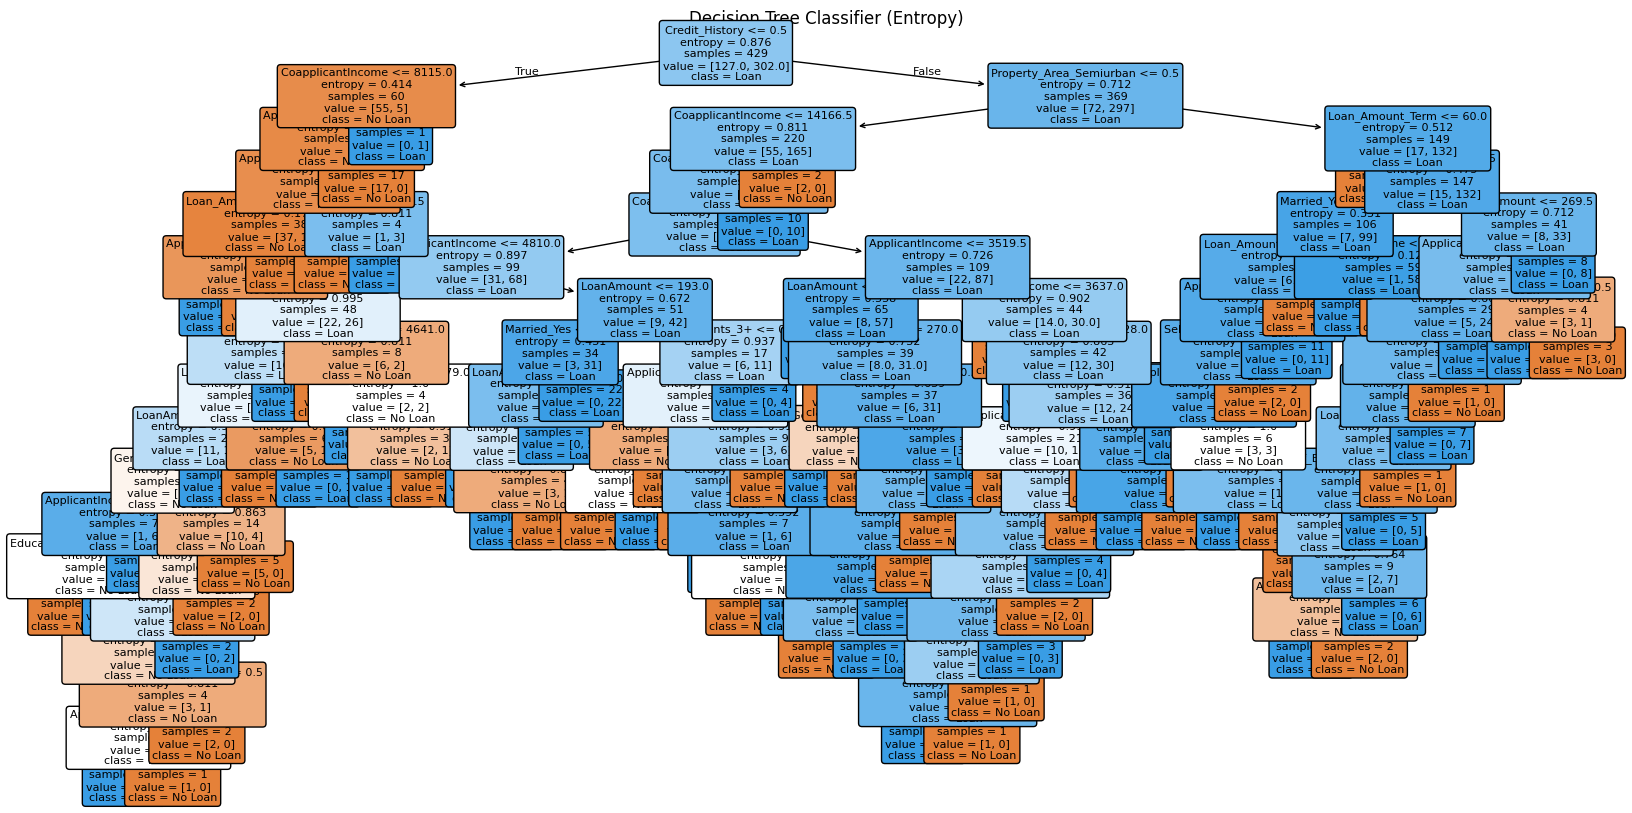

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, feature_names=X.columns, class_names=['No Loan', 'Loan'], filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree Classifier (Entropy)")
plt.show()

### Simplify the Decision Tree (using `max_depth`)

In [12]:
# Initialize and train a simplified Decision Tree Classifier with max_depth=3
dt_classifier_simplified = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt_classifier_simplified.fit(X_train, y_train)

# Make predictions on the test set with the simplified tree
y_pred_simplified = dt_classifier_simplified.predict(X_test)

# Evaluate the simplified model
accuracy_simplified = accuracy_score(y_test, y_pred_simplified)
print(f"Accuracy of Simplified Decision Tree Classifier (max_depth=3): {accuracy_simplified:.2f}")

Accuracy of Simplified Decision Tree Classifier (max_depth=3): 0.78


### Plot the Simplified Decision Tree

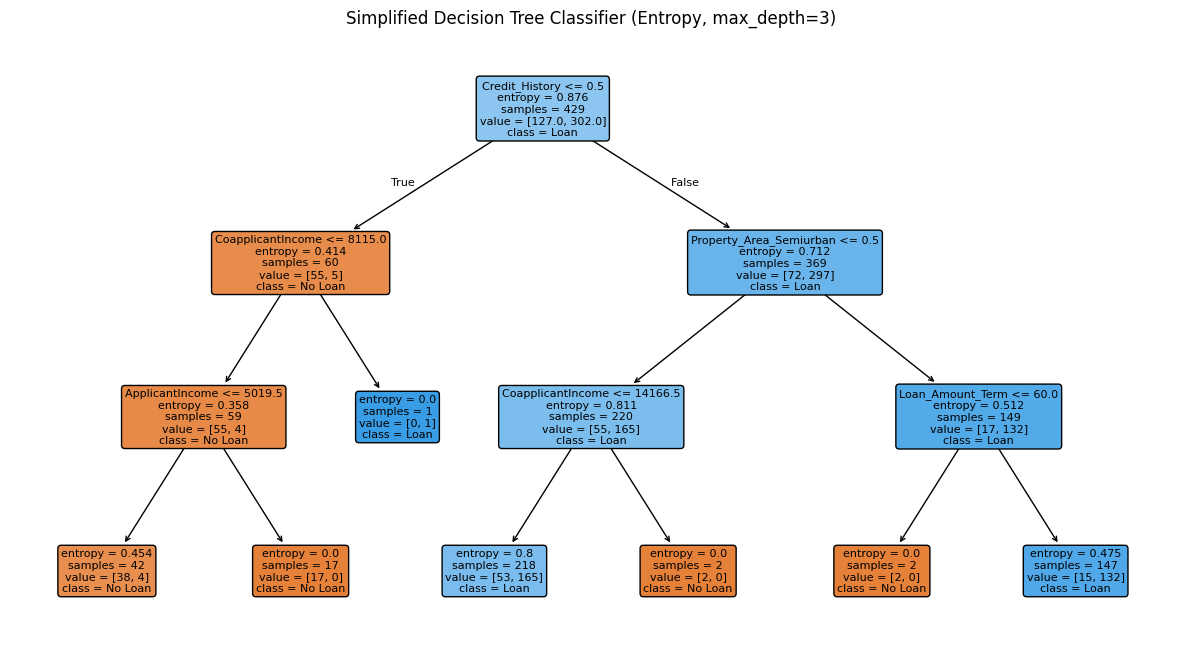

In [13]:
plt.figure(figsize=(15, 8))
plot_tree(dt_classifier_simplified, feature_names=X.columns, class_names=['No Loan', 'Loan'], filled=True, rounded=True, fontsize=8)
plt.title("Simplified Decision Tree Classifier (Entropy, max_depth=3)")
plt.show()